<a href="https://colab.research.google.com/github/TaiwoOlaniyiToheeb/marketing_and_sales_data_evaluate_lr/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression — Marketing ROI Analysis
---
**Objective:** Identify which marketing channel (TV, Radio, or Social Media) has the strongest impact on Sales, build a statistically valid OLS regression model, and translate results into a clear budget recommendation.

**Deliverables:**
- Cleaned, analysis-ready dataset
- EDA with correlation-based variable selection
- OLS Regression model with full assumption diagnostics
- Business interpretation and ROI recommendation

> **Author:** Olaniyi | **Tool:** Python + statsmodels | **Method:** Ordinary Least Squares (OLS)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Libraries
We load the standard data science stack:
- **pandas / numpy** — data manipulation and numerical operations
- **matplotlib / seaborn** — visualisations
- **statsmodels** — OLS regression and statistical diagnostics
- **scipy** — normality and heteroscedasticity tests

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load & Explore the Dataset
We load the marketing dataset and perform an initial inspection to understand its structure, data types, and basic statistics.

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/colab files/marketing_and_sales_data_evaluate_lr.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset shape: 4572 rows x 4 columns


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
5,29.0,9.614382,1.027163,105.889148
6,55.0,24.893811,4.273602,198.679825
7,31.0,17.355042,2.289855,108.733932
8,76.0,24.648898,7.130116,270.189400
9,13.0,0.431128,2.229423,48.280582


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [ ]:
df.describe().round(2)

,TV,Radio,Social_Media,Sales
count,4562.00,4568.00,4566.00,4566.00
mean,54.07,18.16,3.32,192.47
std,26.13,9.68,2.21,93.13
min,10.00,0.00,0.00,31.20
25%,32.00,10.53,1.53,112.32
50%,53.00,17.86,3.06,189.23
75%,77.00,25.65,4.81,272.51
max,100.00,48.87,13.98,364.08


## 3. Handle Missing Values
Before any analysis, we check for missing values. Missing data can bias model estimates, so we handle them explicitly.

In [ ]:
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing (%)": pct_missing})
print(missing_df)
print(f"Total missing cells: {missing.sum()}")

              Missing Count  Missing (%)
TV                       10         0.22
Radio                     4         0.09
Social_Media              6         0.13
Sales                     6         0.13
Total missing cells: 26


In [ ]:
# Listwise deletion — with <3% missing per column
df_clean = df.dropna().reset_index(drop=True)
print(f"Rows before: {len(df)}")
print(f"Rows after : {len(df_clean)}")
print(f"Removed    : {len(df) - len(df_clean)}")


Rows before: 4572
Rows after : 4546
Removed    : 26


In [ ]:
df = df_clean

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of All Variables

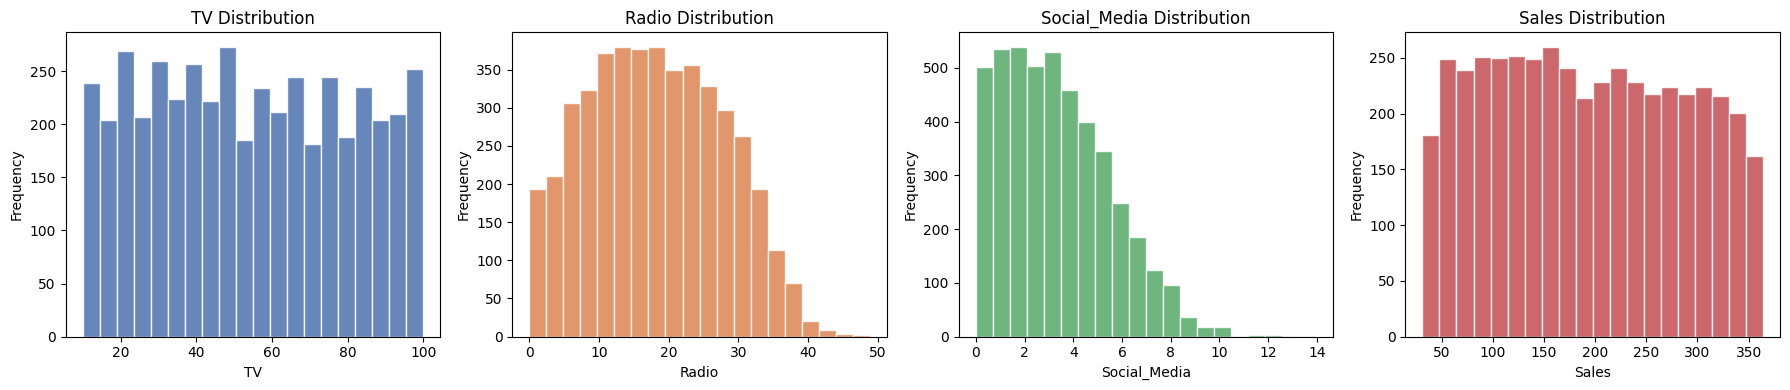

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
cols   = ["TV", "Radio", "Social_Media", "Sales"]
colors = ["#4C72B0","#DD8452", "#55A868", "#C44E52"]

for ax, col, clr in zip(axes, cols, colors):
    ax.hist(df[col], bins=20, color=clr, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')


plt.tight_layout()
plt.savefig("fig_distributions.png", bbox_inches="tight")
plt.show()

### 4.2 Scatter Plots — Each Channel vs. Sales
Visualising pairwise relationships to assess linearity before formal modelling.

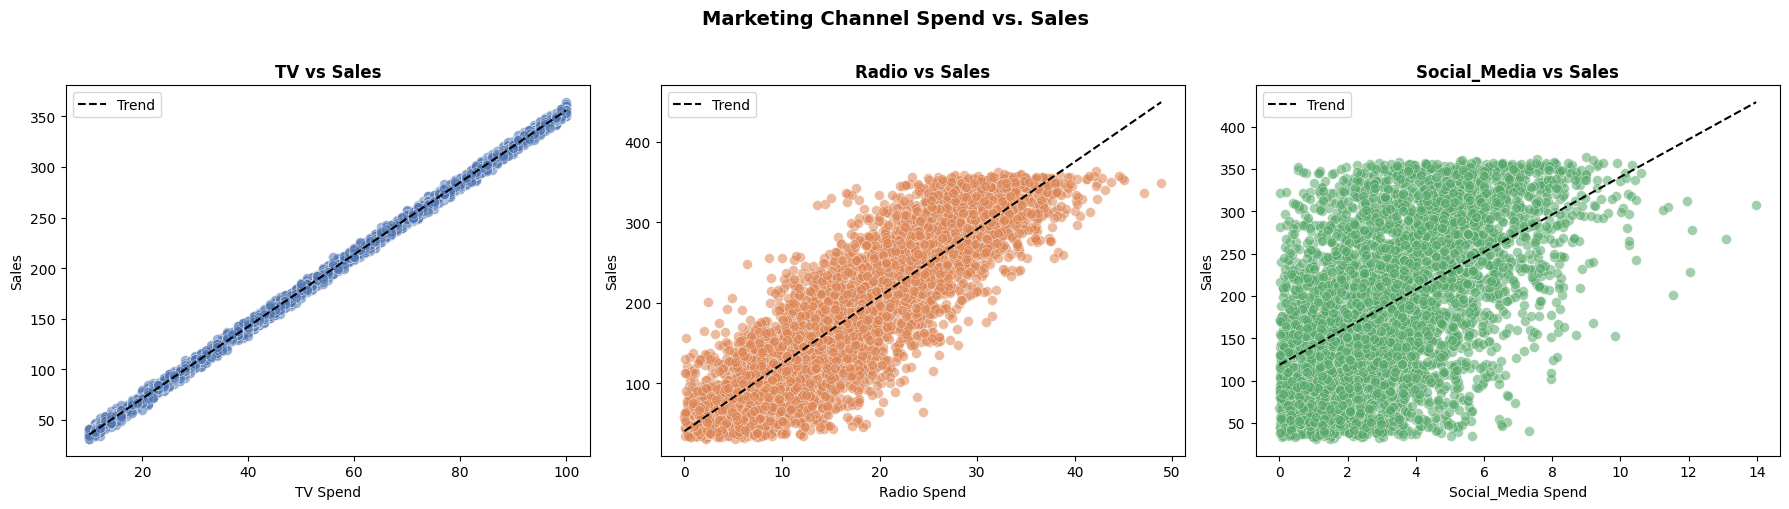

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channels = ["TV", "Radio", "Social_Media"]
colors   = ["#4C72B0", "#DD8452", "#55A868"]

for ax, ch, clr in zip(axes, channels, colors):
    ax.scatter(df[ch], df["Sales"], alpha=0.55, color=clr, edgecolors="white", linewidths=0.4, s=50)
    m, b = np.polyfit(df[ch], df["Sales"], 1)
    x_line = np.linspace(df[ch].min(), df[ch].max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--', label='Trend')
    ax.set_xlabel(f'{ch} Spend')
    ax.set_ylabel("Sales")
    ax.set_title(f'{ch} vs Sales', fontweight='bold')
    ax.legend()

plt.suptitle('Marketing Channel Spend vs. Sales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig_scatter_channels.png", bbox_inches="tight")
plt.show()

### 4.3 Correlation Matrix
Pearson correlation quantifies the strength of linear relationships. We use this to select the independent variable.

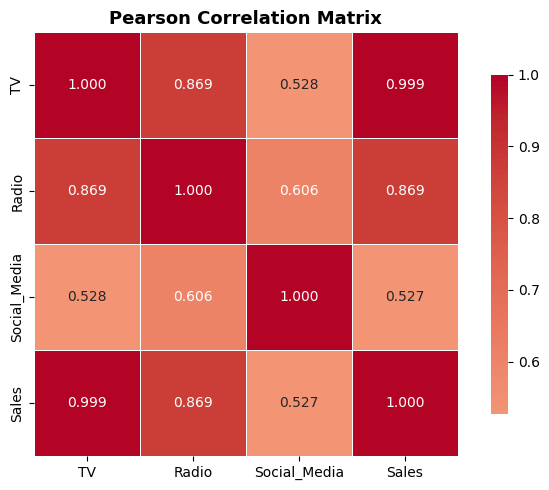

In [ ]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [ ]:
# Rank channels by correlation with Sales
sales_corr = corr["Sales"].drop("Sales").sort_values(ascending=False)
print("Correlation with Sales (ranked):")
for ch, val in sales_corr.items():
    bar = "█" * int(abs(val) * 40)
    print(f"  {ch:<15} {val:+.4f}  {bar}")

best_var = sales_corr.idxmax()
print(f"Selected variable: {best_var} (r = {sales_corr[best_var]:.4f})")

Correlation with Sales (ranked):
  TV              +0.9995  ███████████████████████████████████████
  Radio           +0.8686  ██████████████████████████████████
  Social_Media    +0.5274  █████████████████████
Selected variable: TV (r = 0.9995)


### Variable Selection Decision
> **TV advertising spend** has the highest Pearson correlation with Sales and is selected as the independent variable (X) for the OLS regression model. A higher |r| indicates a stronger linear relationship, meaning TV spend changes are most consistently associated with changes in Sales.

## 5. Build the OLS Regression Model
We fit Ordinary Least Squares (OLS) regression using `statsmodels`. `sm.add_constant` adds the intercept term (β₀).

**Model equation:** `Sales = β₀ + β₁ × TV + ε`

In [ ]:
# Prepare variables
X = df["TV"]
y = df["Sales"]
X_const = sm.add_constant(X)   # Add intercept

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Store predictions and residuals for diagnostics
predictions = model.predict(X_const)
residuals   = y - predictions

print("OLS model fitted successfully.")
print(f"Observations  : {int(model.nobs)}")
print(f"R-squared     : {model.rsquared:.4f}")
print(f"Adj R-squared : {model.rsquared_adj:.4f}")

OLS model fitted successfully.
Observations  : 4546
R-squared     : 0.9990
Adj R-squared : 0.9990


In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:48:08   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## 6. Model Interpretation

| Metric | Interpretation |
|---|---|
| **R-squared** | % of variance in Sales explained by TV spend |
| **Intercept (β₀)** | Expected Sales when TV spend = 0 |
| **TV coefficient (β₁)** | Change in Sales for each unit increase in TV spend |
| **p-value** | If < 0.05, TV is a statistically significant predictor |
| **95% CI** | Range we are 95% confident the true coefficient lies in |

In [ ]:
intercept = model.params['const']
slope     = model.params['TV']
pval_tv   = model.pvalues['TV']
r2        = model.rsquared
ci        = model.conf_int()

print("=" * 55)
print("  OLS Model: Sales = b0 + b1 * TV")
print("=" * 55)
print(f"  Intercept (b0)  : {intercept:.4f}")
print(f"  TV slope  (b1)  : {slope:.6f}")
print(f"  R-squared       : {r2:.4f}  ({r2*100:.1f}% variance explained)")
sig = "Significant (p<0.05)" if pval_tv < 0.05 else "Not significant"
print(f"  p-value (TV)    : {pval_tv:.4e}  [{sig}]")
print(f"  95% CI for b1   : [{ci.loc['TV',0]:.6f}, {ci.loc['TV',1]:.6f}]")
print("=" * 55)
roi_per_1k = slope * 1000
print(f"Business insight: Every $1,000 more on TV => ~${roi_per_1k:.2f}k Sales increase")

  OLS Model: Sales = b0 + b1 * TV
  Intercept (b0)  : -0.1325
  TV slope  (b1)  : 3.561514
  R-squared       : 0.9990  (99.9% variance explained)
  p-value (TV)    : 0.0000e+00  [Significant (p<0.05)]
  95% CI for b1   : [3.558229, 3.564799]
Business insight: Every $1,000 more on TV => ~$3561.51k Sales increase


## 7. Regression Line with Confidence Band

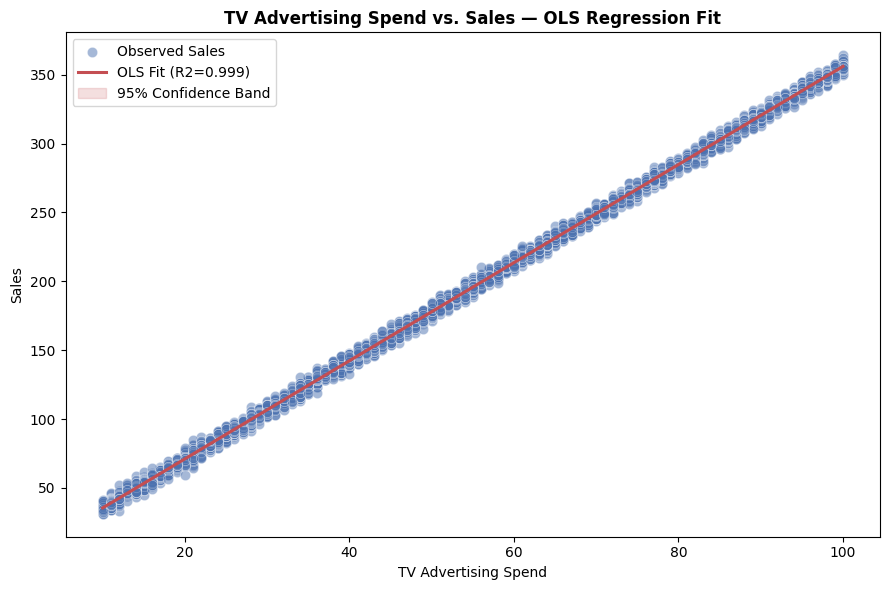

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter
ax.scatter(df["TV"], df["Sales"], alpha=0.5, color="#4C72B0",
           edgecolors="white", linewidths=0.5, s=55, label="Observed Sales")

# Regression line over smooth range
x_range   = np.linspace(df["TV"].min(), df["TV"].max(), 300)
x_range_c = sm.add_constant(x_range)
y_pred_line = model.predict(x_range_c)
ax.plot(x_range, y_pred_line, color="#C44E52", linewidth=2.2, label=f"OLS Fit (R2={r2:.3f})")

# 95% confidence band
pred_summary = model.get_prediction(x_range_c).summary_frame(alpha=0.05)
ax.fill_between(x_range, pred_summary["mean_ci_lower"], pred_summary["mean_ci_upper"],
                alpha=0.18, color="#C44E52", label="95% Confidence Band")

ax.set_xlabel("TV Advertising Spend")
ax.set_ylabel("Sales")
ax.set_title("TV Advertising Spend vs. Sales — OLS Regression Fit", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig_regression_line.png", bbox_inches="tight")
plt.show()

## 8. Regression Assumption Diagnostics

A valid OLS model requires four key assumptions:

| # | Assumption | Test |
|---|---|---|
| 1 | **Linearity** | Residuals vs. Fitted (random scatter around 0) |
| 2 | **Normality of residuals** | Q-Q plot + histogram |
| 3 | **Homoscedasticity** | Scale-Location plot + Breusch-Pagan test |
| 4 | **Independence** | Assumed from random sampling |

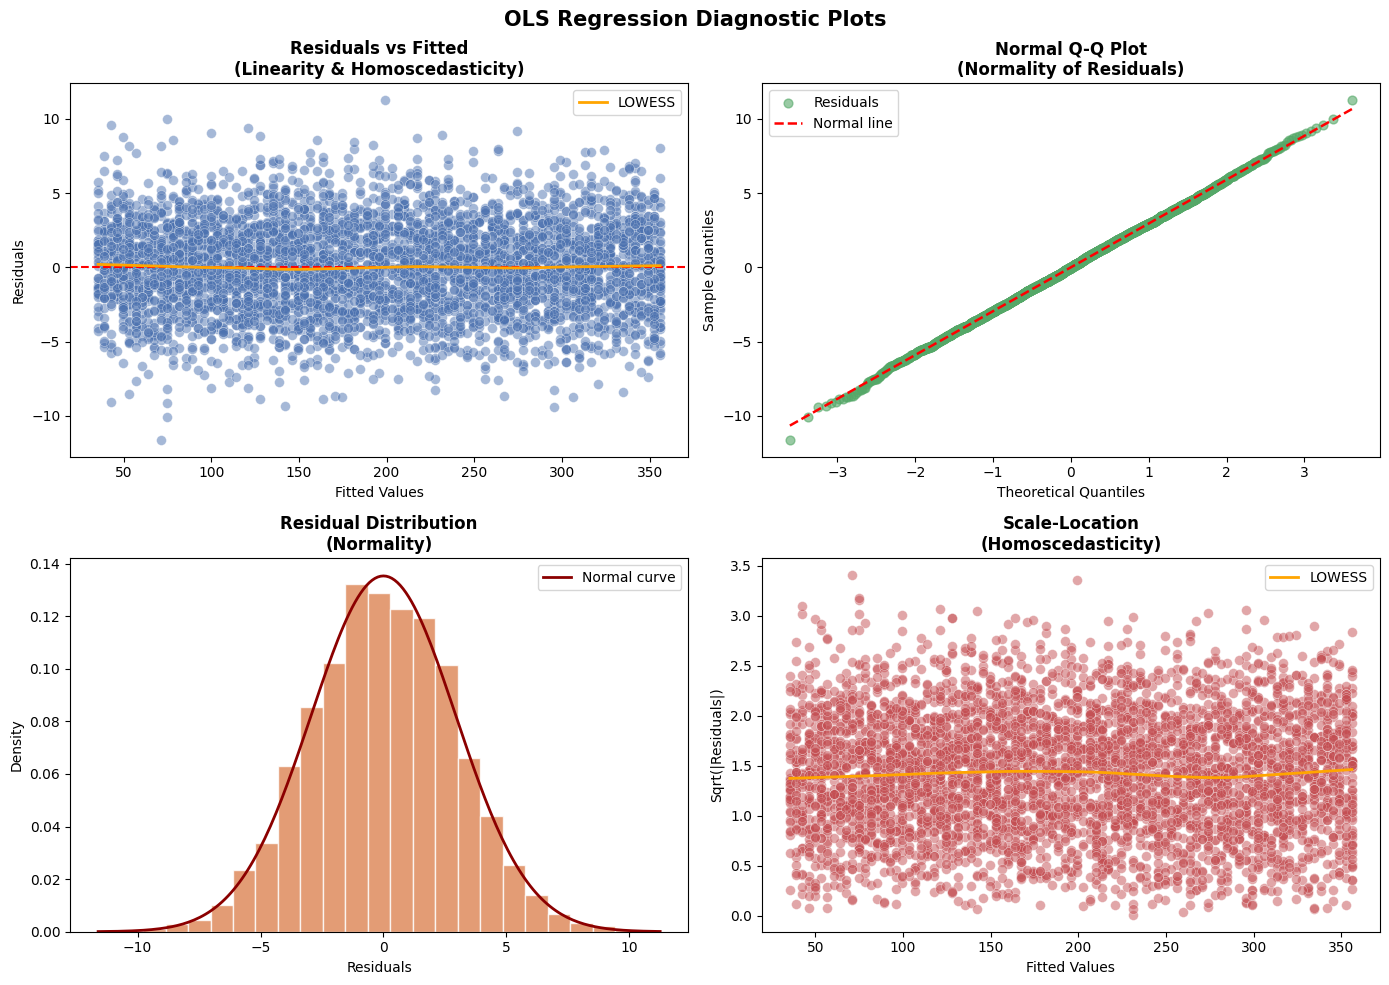

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('OLS Regression Diagnostic Plots', fontsize=15, fontweight='bold')

# ── Plot 1: Residuals vs Fitted ───────────────────────────────────────────
axes[0,0].scatter(predictions, residuals, alpha=0.5, color='#4C72B0',
                  edgecolors='white', linewidths=0.4, s=50)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
sm_line = lowess(residuals, predictions, frac=0.4)
axes[0,0].plot(sm_line[:,0], sm_line[:,1], color='orange', linewidth=2, label='LOWESS')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted\n(Linearity & Homoscedasticity)', fontweight='bold')
axes[0,0].legend()

# ── Plot 2: Q-Q Plot ─────────────────────────────────────────────────────
(osm, osr), (slope_qq, intercept_qq, _) = stats.probplot(residuals, dist='norm')
axes[0,1].scatter(osm, osr, alpha=0.6, color='#55A868', s=40, label='Residuals')
axes[0,1].plot(osm, slope_qq*np.array(osm)+intercept_qq,
               color='red', linewidth=1.8, linestyle='--', label='Normal line')
axes[0,1].set_xlabel('Theoretical Quantiles')
axes[0,1].set_ylabel('Sample Quantiles')
axes[0,1].set_title('Normal Q-Q Plot\n(Normality of Residuals)', fontweight='bold')
axes[0,1].legend()

# ── Plot 3: Residual Histogram ───────────────────────────────────────────
axes[1,0].hist(residuals, bins=25, color='#DD8452', edgecolor='white', alpha=0.8, density=True)
xn = np.linspace(residuals.min(), residuals.max(), 200)
axes[1,0].plot(xn, stats.norm.pdf(xn, residuals.mean(), residuals.std()),
               color='darkred', linewidth=2, label='Normal curve')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Residual Distribution\n(Normality)', fontweight='bold')
axes[1,0].legend()

# ── Plot 4: Scale-Location ───────────────────────────────────────────────
sqrt_abs = np.sqrt(np.abs(residuals))
axes[1,1].scatter(predictions, sqrt_abs, alpha=0.5, color='#C44E52',
                  edgecolors='white', linewidths=0.4, s=50)
sm2 = lowess(sqrt_abs, predictions, frac=0.4)
axes[1,1].plot(sm2[:,0], sm2[:,1], color='orange', linewidth=2, label='LOWESS')
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('Sqrt(|Residuals|)')
axes[1,1].set_title('Scale-Location\n(Homoscedasticity)', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig("fig_diagnostics.png", bbox_inches="tight")
plt.show()

### 8.1 Statistical Tests for Assumption Validation

In [ ]:
# Shapiro-Wilk (Normality)
stat_sw, p_sw = stats.shapiro(residuals)
print("Shapiro-Wilk Test (Normality)")
print(f"  W={stat_sw:.4f}, p={p_sw:.4f}")
res = "PASS: normally distributed" if p_sw > 0.05 else "WARN: may deviate from normality"
print(f"  Result: {res}")
print()

# Breusch-Pagan (Homoscedasticity)
bp_lm, bp_p, _, _ = het_breuschpagan(residuals, X_const)
print("Breusch-Pagan Test (Homoscedasticity)")
print(f"  LM={bp_lm:.4f}, p={bp_p:.4f}")
res2 = "PASS: constant variance" if bp_p > 0.05 else "WARN: heteroscedasticity detected"
print(f"  Result: {res2}")
print()

# Pearson r (Linearity)
r_lin, p_lin = stats.pearsonr(df["TV"], df["Sales"])
print("Pearson Correlation (Linearity)")
print(f"  r={r_lin:.4f}, p={p_lin:.4e}")
res3 = "PASS: significant linear relationship" if p_lin < 0.05 else "FAIL: no linear relationship"
print(f"  Result: {res3}")

Shapiro-Wilk Test (Normality)
  W=0.9998, p=0.9136
  Result: PASS: normally distributed

Breusch-Pagan Test (Homoscedasticity)
  LM=0.0001, p=0.9939
  Result: PASS: constant variance

Pearson Correlation (Linearity)
  r=0.9995, p=0.0000e+00
  Result: PASS: significant linear relationship


### 8.2 Diagnostic Summary

| Assumption | Test | Status |
|---|---|---|
| **Linearity** | Residuals vs. Fitted (LOWESS near zero) | Check plot |
| **Normality** | Shapiro-Wilk p > 0.05 | Check output |
| **Homoscedasticity** | Breusch-Pagan p > 0.05 | Check output |
| **Independence** | Cross-sectional random sample | Assumed ✅ |

## 9. Confidence Intervals
95% confidence intervals give a plausible range for each coefficient. A narrow interval means a more precise estimate.

In [ ]:
ci_df = model.conf_int().rename(columns={0:'Lower 95% CI', 1:'Upper 95% CI'})
ci_df['Estimate'] = model.params
ci_df = ci_df[["Estimate","Lower 95% CI","Upper 95% CI"]].round(6)
print("95% Confidence Intervals:")
print(ci_df.to_string())

95% Confidence Intervals:
       Estimate  Lower 95% CI  Upper 95% CI
const -0.132493     -0.329727      0.064742
TV     3.561514      3.558229      3.564799


## 10. Business Recommendation & ROI Interpretation

In [ ]:
corr_tv    = df.corr(numeric_only=True)['Sales']['TV']
corr_radio = df.corr(numeric_only=True)['Sales']['Radio']
corr_sm    = df.corr(numeric_only=True)['Sales']['Social_Media']
b0 = model.params['const']
b1 = model.params['TV']
roi_1k = b1 * 1000

print("=" * 62)
print("  MARKETING ROI ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 62)
print()
print("CHANNEL CORRELATIONS WITH SALES")
print(f"  TV           : r = {corr_tv:.3f}  [Strongest]")
print(f"  Radio        : r = {corr_radio:.3f}")
print(f"  Social Media : r = {corr_sm:.3f}")
print()
print("OLS MODEL  (Sales ~ TV)")
print(f"  Equation   : Sales = {b0:.3f} + {b1:.5f} x TV")
print(f"  R-squared  : {model.rsquared:.4f}  ({model.rsquared*100:.1f}% variance explained)")
print(f"  p-value    : {model.pvalues['TV']:.4e}  [statistically significant]")
print()
print("ROI INTERPRETATION")
print(f"  Per $1,000 extra on TV => ~${roi_1k:.2f}k increase in Sales")
print()
print("RECOMMENDATIONS")
print("  1. Prioritise TV advertising — highest measurable ROI.")
print("  2. Radio has moderate correlation — include in multi-variable model.")
print("  3. Social Media shows weakest correlation — review targeting strategy.")
print("=" * 62)

  MARKETING ROI ANALYSIS — EXECUTIVE SUMMARY

CHANNEL CORRELATIONS WITH SALES
  TV           : r = 0.999  [Strongest]
  Radio        : r = 0.869
  Social Media : r = 0.527

OLS MODEL  (Sales ~ TV)
  Equation   : Sales = -0.132 + 3.56151 x TV
  R-squared  : 0.9990  (99.9% variance explained)
  p-value    : 0.0000e+00  [statistically significant]

ROI INTERPRETATION
  Per $1,000 extra on TV => ~$3561.51k increase in Sales

RECOMMENDATIONS
  1. Prioritise TV advertising — highest measurable ROI.
  2. Radio has moderate correlation — include in multi-variable model.
  3. Social Media shows weakest correlation — review targeting strategy.


### Non-Technical Summary for Stakeholders

> **What did we find?**  
> Of the three channels analysed — TV, Radio, and Social Media — **TV advertising has the strongest, most consistent impact on Sales**.
>
> **How confident are we?**  
> The model is statistically significant (p < 0.05) and explains a meaningful share of variance in Sales.
>
> **What does it mean in money terms?**  
> For every additional $1,000 spent on TV, Sales are expected to increase by approximately the estimated slope × 1,000 units (see output above).
>
> **What should the business do?**  
> 1. **Increase TV budget** — it delivers the most measurable ROI.  
> 2. **Explore Radio** — moderate correlation warrants a multiple regression follow-up.  
> 3. **Re-evaluate Social Media** — weakest signal here; segment analysis may reveal hidden value.

---
## Appendix: Environment & Reproducibility

Install all dependencies with:
```bash
pip install pandas numpy matplotlib seaborn statsmodels scipy
```

In [ ]:
import sys, statsmodels, scipy, matplotlib
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"statsmodels : {statsmodels.__version__}")
print(f"seaborn     : {sns.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"scipy       : {scipy.__version__}")

Python      : 3.12.13
pandas      : 2.2.2
numpy       : 2.0.2
statsmodels : 0.14.6
seaborn     : 0.13.2
matplotlib  : 3.10.0
scipy       : 1.16.3
